In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style(style = "darkgrid")

In [2]:
df = pd.read_csv(r"C:\Projects\Training\Week2\dataset\housing.csv")
print(df.head())
print("\nShape of the entire dataset.",df.shape)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

Shape of the entire dataset. (20640, 10)


1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None


In [4]:
# categorical column
categorical_column = df["ocean_proximity"]
print(categorical_column.nunique())
print(categorical_column.unique())

5
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
print(df.isnull().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [7]:
# filling up the missing values with mean on total_bedrooms
# df["total_bedrooms"] = df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
# df.isna().sum()

df.dropna(subset=["total_bedrooms"], inplace= True)
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [8]:
df = df.drop("ocean_proximity", axis = 1)
df.info()

<class 'pandas.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
dtypes: float64(9)
memory usage: 1.6 MB


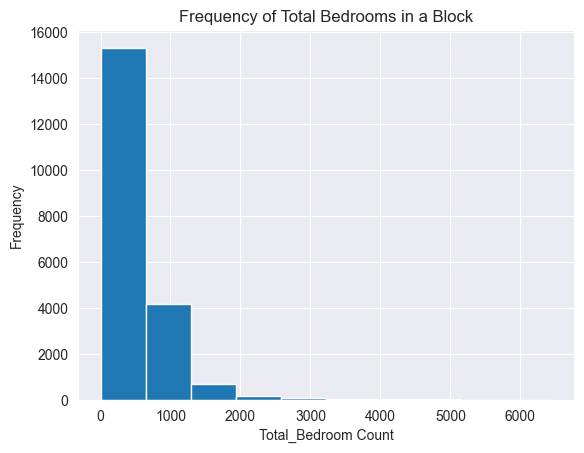

In [9]:
# plotting the values
plt.title(label = "Frequency of Total Bedrooms in a Block")
plt.hist(df["total_bedrooms"])
plt.xlabel("Total_Bedroom Count")
plt.ylabel("Frequency")
plt.show()

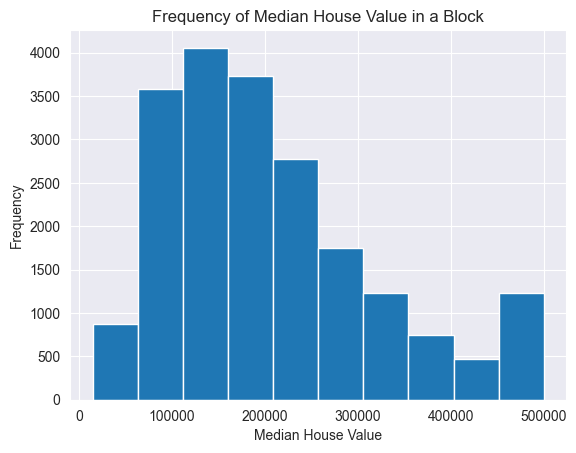

In [10]:
plt.title(label = "Frequency of Median House Value in a Block")
plt.hist(df["median_house_value"])
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()

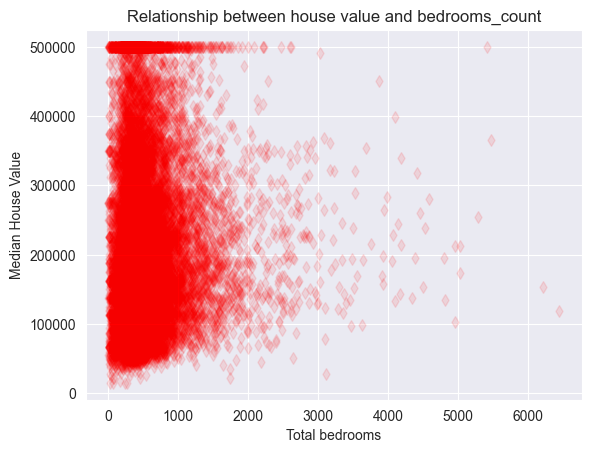

In [11]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["total_bedrooms"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total bedrooms")
plt.ylabel("Median House Value")
plt.show()

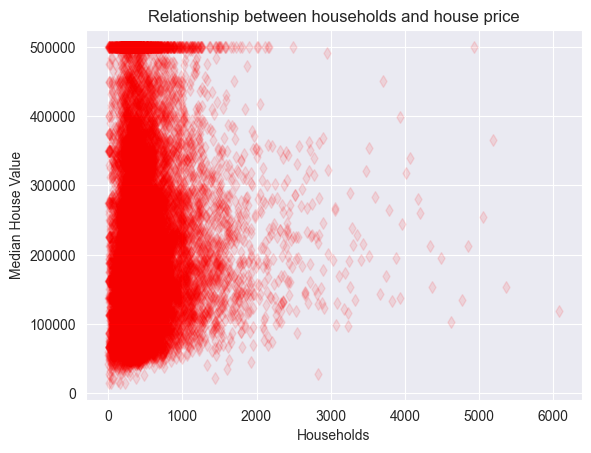

In [12]:
plt.title("Relationship between households and house price")
plt.scatter(df["households"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Households")
plt.ylabel("Median House Value")
plt.show()

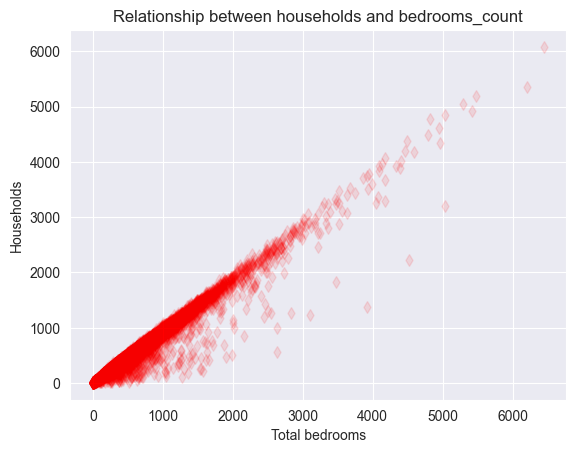

In [13]:
plt.title("Relationship between households and bedrooms_count")
plt.scatter(df["total_bedrooms"], y = df["households"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total bedrooms")
plt.ylabel("Households")
plt.show()

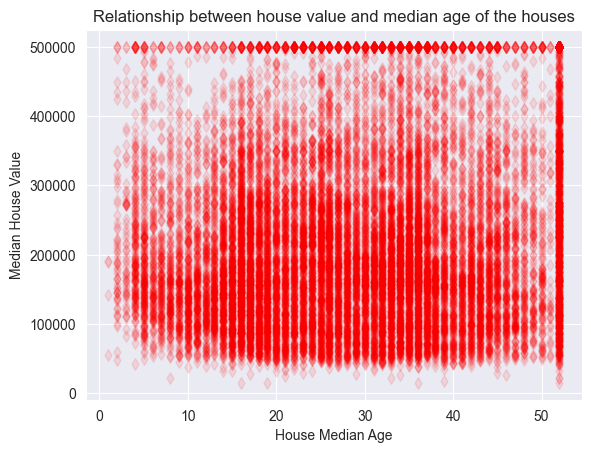

In [14]:
plt.title("Relationship between house value and median age of the houses")
plt.scatter(df["housing_median_age"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("House Median Age")
plt.ylabel("Median House Value")
plt.show()

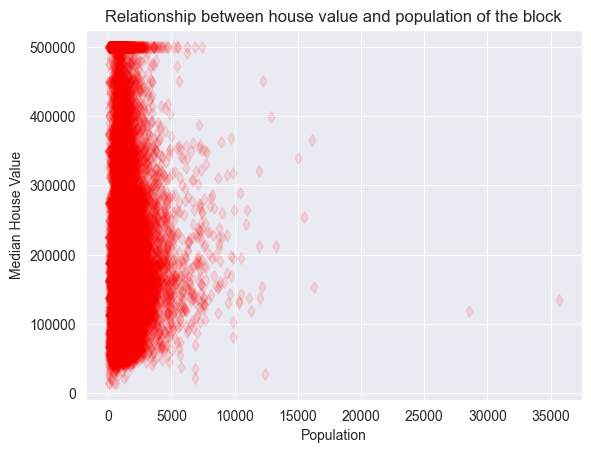

In [15]:
plt.title("Relationship between house value and population of the block")
plt.scatter(df["population"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Population")
plt.ylabel("Median House Value")
plt.show()

In [31]:
population = df["population"][df["median_house_value"] > 300000]
population.count()

np.int64(3800)

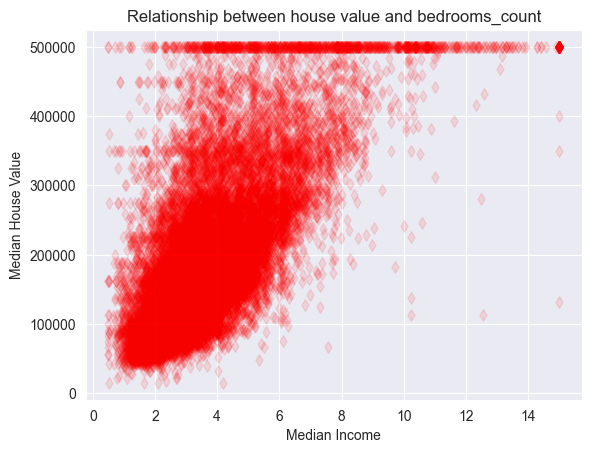

In [16]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["median_income"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

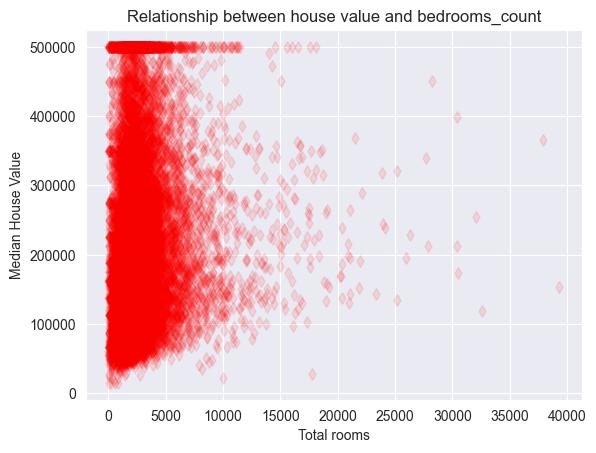

In [17]:
plt.title("Relationship between house value and bedrooms_count")
plt.scatter(df["total_rooms"], y = df["median_house_value"], marker= "d", c = "r", alpha= 0.1)
plt.xlabel("Total rooms")
plt.ylabel("Median House Value")
plt.show()

In [21]:
X = df.drop("median_house_value", axis = 1)
y = df.median_house_value

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print("x_train", X_train.shape)
print("x_test", X_test.shape)
print("y_train", y_train.shape)
print("y_test", y_test.shape)

x_train (16346, 8)
x_test (4087, 8)
y_train (16346,)
y_test (4087,)


<class 'numpy.ndarray'>


In [ ]:
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)


[[166300.]
 [ 97600.]
 [ 71400.]
 ...
 [110900.]
 [205100.]
 [ 92400.]]


In [38]:
print(X_train)

[[-116.94     32.84     32.     ...  778.      262.        4.5278]
 [-117.27     34.14     35.     ...  658.      245.        4.4435]
 [-119.74     36.79     28.     ... 1614.      592.        2.1573]
 ...
 [-120.17     39.33     18.     ...  486.      179.        4.119 ]
 [-121.94     38.36      2.     ... 1791.      562.        5.0346]
 [-118.27     33.94     34.     ...  661.      171.        2.0789]]


In [45]:
# Z-score normalization
# (x - mean)/standard deviation

scaled_X_train = X_train - np.mean(X_train, axis = 0) / np.std(X_train, axis = 0)
scaled_X_test = X_test - np.mean(X_test, axis = 0) / np.std(X_test, axis = 0)

In [ ]:
# Univariate Linear Regression

income_train = scaled_X_train[:, 7:8]
income_test = scaled_X_test[:, 7:8]
y_train_uni = y_train
y_test_uni = y_test

[[ 3.47206265]
 [ 0.96686265]
 [ 2.19906265]
 ...
 [ 2.68906265]
 [-0.07183735]
 [ 1.91406265]]
